<a href="https://colab.research.google.com/github/Marcomaltoni/Advanced_deep_learning/blob/main/MNIST_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install denoising_diffusion_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 5.5 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import drive
from torch.utils.tensorboard import SummaryWriter
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import sys

from denoising_diffusion_pytorch import Unet, GaussianDiffusion

In [ ]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"I'm using: {device}")

I'm using: cuda


# Downloading the dataset #

In [ ]:
# Hyperparameters
learning_rate = 4e-4
batch_size = 128  # Batch size
n_epochs = 100
image_size = 28
time_steps = 1000 #steps in training phase
sampling_timesteps = 250 #steps in generation phase: thanks to DDIM formula the model can skip timesteps making predictions about n steps forward

In [ ]:
# we define a tranform that converts the image to tensor, keep the colour normalization as it
# is in [0,1] as it is the best normalization for this problem
myTransforms = transforms.Compose([transforms.ToTensor()])

In [ ]:
# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loading MNIST digits dataset


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.50MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.08MB/s]


In [ ]:
test_dataset = datasets.MNIST(root='dataset/', train=False, download=False, transform=myTransforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class_names = dataset.classes

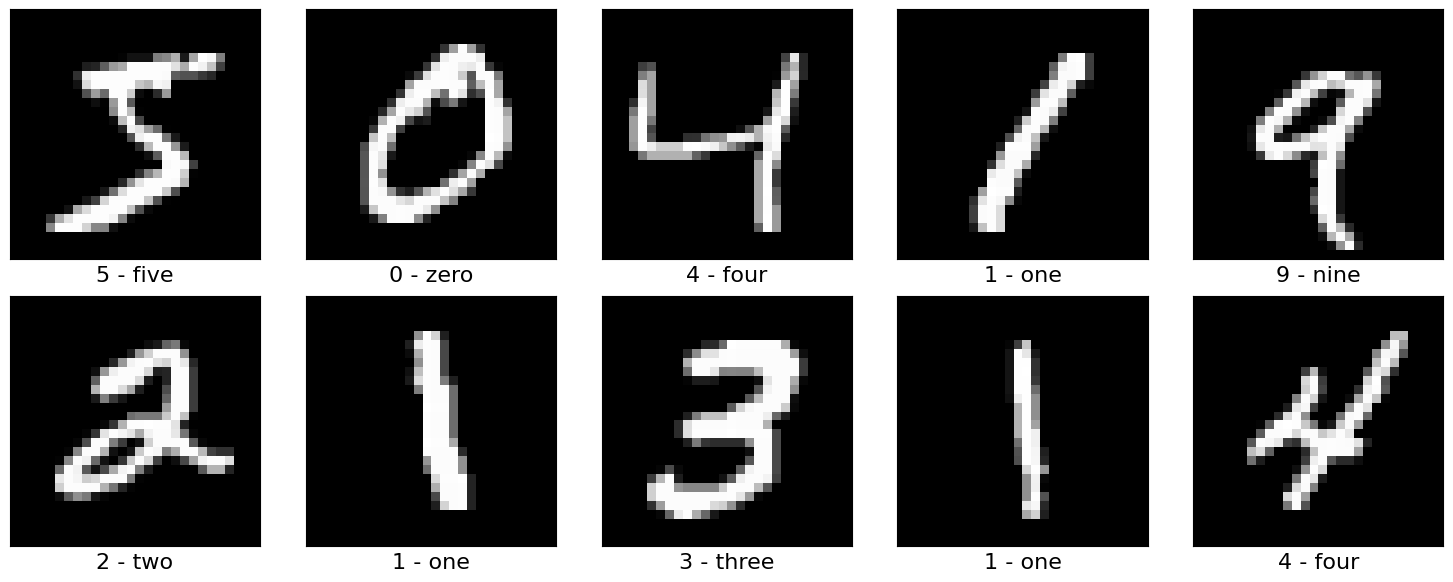

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = ax.flatten()

for i in range(10):
    image, label = dataset[i]

    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].grid(False)
    ax[i].imshow(image.squeeze(), cmap=plt.cm.gray)
    ax[i].set_xlabel(class_names[label])

plt.tight_layout()
plt.show()

#Generation of MNIST images using a diffusion model (U-Net) #

The U-Net is a convolutional architecture that takes a noisy image and processes it through a series of downsampling layers to extract multi-scale features, before a decoder part restores the initial spatial dimensions in order to predict the noise added pixel by pixel. An additional key feature is the presence of skip connections, which allow the decoder layers to receive high-resolution spatial information directly from the corresponding encoder layers. These feature maps are stored in VRAM during the forward pass and concatenated to the decoder's activations, ensuring the network retains precise pixel-level coordinates.

In the `denoising_diffusion_pytorch`  library, all the mathematical steps are abstracted into functions. The class `GaussianDiffusion` acts as the director of both the denoising and generation loops by injecting noise, storing the schedules for the forward process, and computing the loss between the injected noise and the model's output. It also orchestrates image generation starting from pure noise.

* The forward process is built upon the DDPM framework. While the theoretical model is a Markov chain where noise is added step-by-step, we can sample any arbitrary timestep $t$ directly using the closed-form formula:$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$$A high number of timesteps ($T$) is used during training to approximate the noising process to a continuous injection of infinitesimal noise.

* The generation process leverages this continuum approximation to switch to the DDIM framework. Since the trajectory is smooth, it is no longer necessary to invert the process step-by-step. The sampling can be reformulated as a non-Markovian process and solved via numerical integration methods analogous to ODE solvers. This makes the generation deterministic, allows the algorithm to skip timesteps, and drastically accelerates inference.

In [ ]:
dim = 32
dim_mults = (1, 2, 5)
model = Unet(
    dim = dim, #first layer channel input: first convolutional layer takes one channel and converts it into 32 channels
    dim_mults = dim_mults, #This means that encoder and decoder have three layers after the first one: each of encoder downsample the dimension of factor 2. The first
    # layer keeps the same channel dimension (1), the second multiplies it by two (2), the third multiplies it by 5 (5). This means that starting by [1,28,28], it is
    #convenient to make the input dimension a power of 2, in this case 32. The output of various layers is output are [32,32,32], [32,16,16], [64,8,8], [160,4,4].
    #The decoder part inverts this process.
    flash_attn = False, # Swithc off an algorithm for attention computation
    channels = 1 # Dimension of input channel
)

In [ ]:
diffusion = GaussianDiffusion(
    model,
    image_size = image_size,
    timesteps = time_steps, # number of steps for forward process: use a lot of steps as in this way the model approximate the noising process to a continuum process
    sampling_timesteps = sampling_timesteps    # number of sampling timesteps (using DDIM for faster inference): as the denoising process was appoximated to be continuum
    # it is not necessary anymore to invert the denoising step by step, but the problem can be seen as an integration problem over a continuum function and it allows
    # to skip some timesteps in order to gain a faster generation. The training still uses a Markovian chain for the noising process (same as the DDPM), but then the
    # generation is made much faster using a non-Markovian process to denoise and get to the generated image (equivalent to solve a differential equation). The
    # denoising steps are in this way made independent from the previous step (non-Markovian process) and the generation becomes a deterministic process.
)


In [ ]:
model.to(device)
diffusion.to(device)

GaussianDiffusion(
  (model): Unet(
    (init_conv): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (time_mlp): Sequential(
      (0): SinusoidalPosEmb()
      (1): Linear(in_features=32, out_features=128, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=128, out_features=128, bias=True)
    )
    (downs): ModuleList(
      (0): ModuleList(
        (0-1): 2 x ResnetBlock(
          (mlp): Sequential(
            (0): SiLU()
            (1): Linear(in_features=128, out_features=64, bias=True)
          )
          (block1): Block(
            (proj): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm): RMSNorm()
            (act): SiLU()
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (block2): Block(
            (proj): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm): RMSNorm()
            (act): SiLU()
            (dropout): Dropout(p=0.0, 

In [ ]:
#AdamW applies a regularization through "decoupled weight decay" weight decay. This improves the model generalization on test dataset.

optim = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [ ]:
loss_train = []
loss_val = []

for epoch in range(n_epochs):
  model.train()
  loss_train_val = []
  for step, (image, label) in enumerate(loader):
    image = image.to(device)
    loss = diffusion(image)
    loss_train_val.append(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()

    if (step + 1) % 10 == 0:
      sys.stdout.write(f"\rEpoch [{epoch + 1}/{n_epochs}], Step [{step + 1}/{len(loader)}], Loss: {loss.item():.4f}")
      sys.stdout.flush()

  loss_train.append(np.mean(loss_train_val))

  loss_val_val = []
  model.eval()
  with torch.no_grad():
    for image,label in test_loader:
      image = image.to(device)
      loss = diffusion(image)
      loss_val_val.append(loss.item())

    loss_val.append(np.mean(loss_val_val))
    print(f"\rEpoch [{epoch + 1}/{n_epochs}] Completed | Train Loss: {np.mean(loss_train_val):.4f} | Val Loss: {np.mean(loss_val_val):.4f}")

Epoch [1/100] Completed | Train Loss: 0.0963 | Val Loss: 0.0522
Epoch [2/100] Completed | Train Loss: 0.0492 | Val Loss: 0.0454
Epoch [3/100] Completed | Train Loss: 0.0446 | Val Loss: 0.0426
Epoch [4/100] Completed | Train Loss: 0.0423 | Val Loss: 0.0411
Epoch [5/100] Completed | Train Loss: 0.0409 | Val Loss: 0.0403
Epoch [6/100] Completed | Train Loss: 0.0401 | Val Loss: 0.0398
Epoch [7/100] Completed | Train Loss: 0.0398 | Val Loss: 0.0393
Epoch [8/100] Completed | Train Loss: 0.0394 | Val Loss: 0.0386
Epoch [9/100] Completed | Train Loss: 0.0385 | Val Loss: 0.0378
Epoch [10/100] Completed | Train Loss: 0.0385 | Val Loss: 0.0400
Epoch [11/100] Completed | Train Loss: 0.0383 | Val Loss: 0.0378
Epoch [12/100] Completed | Train Loss: 0.0374 | Val Loss: 0.0379
Epoch [13/100] Completed | Train Loss: 0.0378 | Val Loss: 0.0369
Epoch [14/100] Completed | Train Loss: 0.0375 | Val Loss: 0.0378
Epoch [15/100] Completed | Train Loss: 0.0373 | Val Loss: 0.0377
Epoch [16/100] Completed | Train L

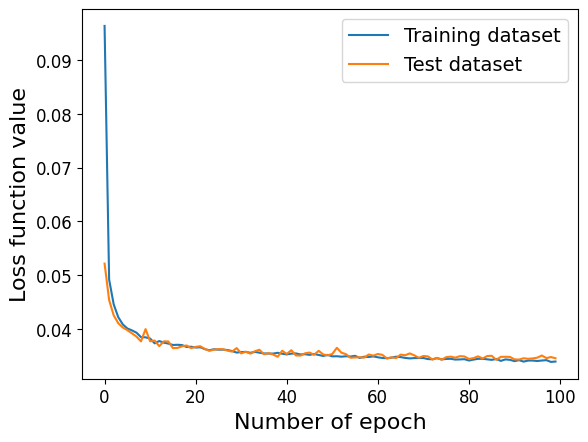

In [ ]:
plt.figure()
plt.xlabel('Number of epoch')
plt.ylabel('Loss function value')
plt.plot(range(n_epochs), loss_train, label='Training dataset')
plt.plot(range(n_epochs), loss_val, label='Test dataset')
plt.legend()
plt.show()

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

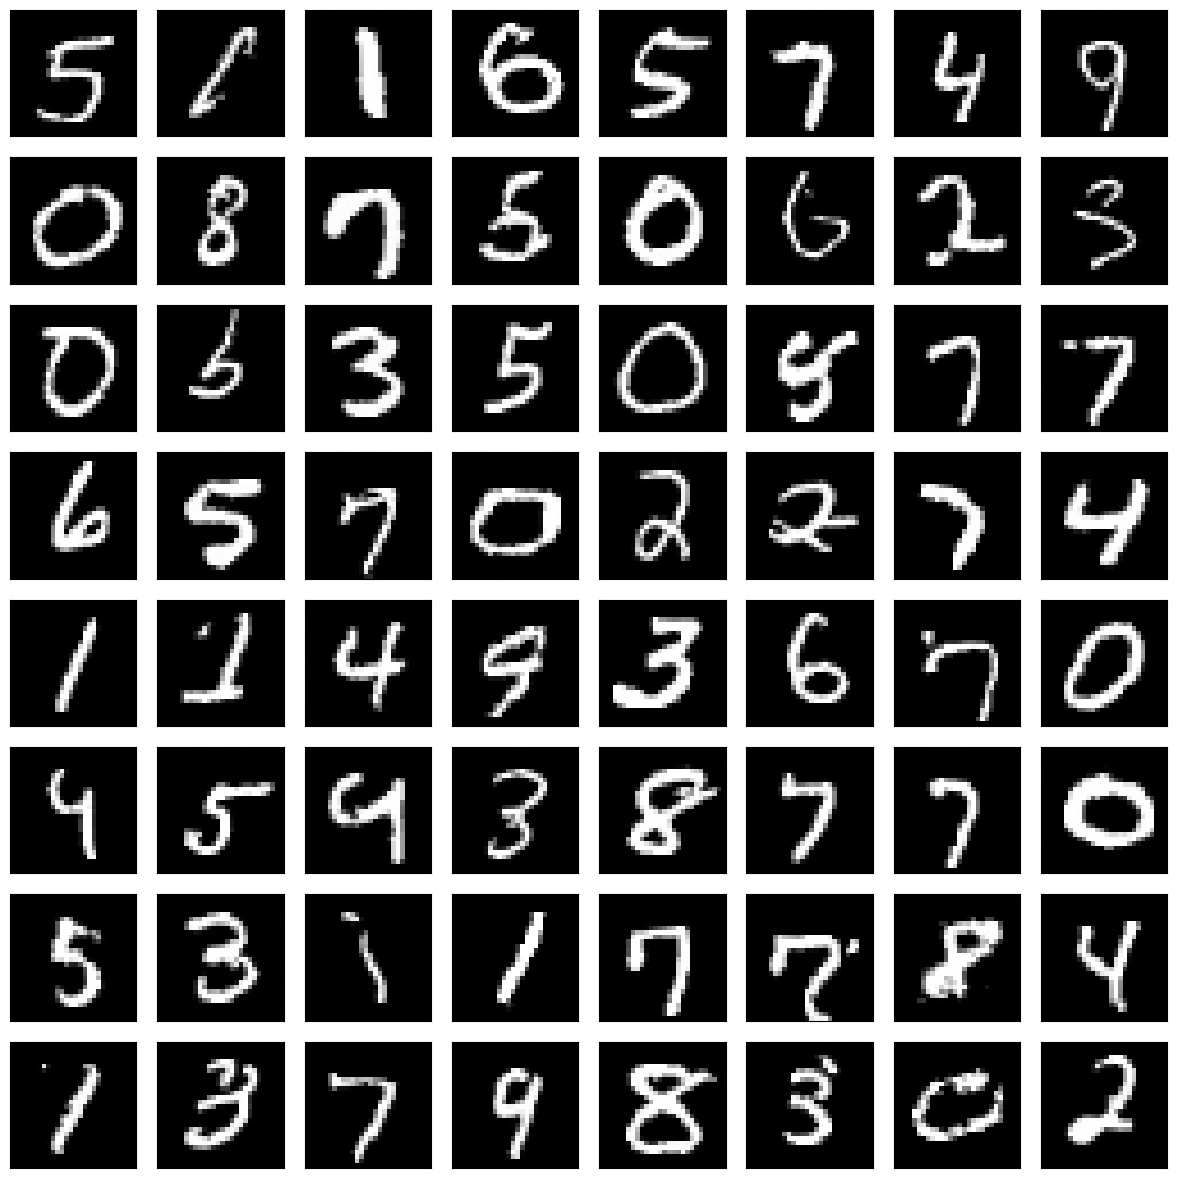

In [ ]:
model.eval()
with torch.no_grad():
  sampled_images = diffusion.sample(batch_size = 64) #Starting from noisy sample images are generated through 250 steps of denoising
  fig, ax = plt.subplots(nrows=8, ncols=8, figsize=(12, 12))
  ax = ax.flatten()

  for i in range(64):

      ax[i].set_xticks([])
      ax[i].set_yticks([])
      ax[i].grid(False)
      ax[i].imshow(sampled_images[i].squeeze().cpu().numpy(), cmap=plt.cm.gray)

  plt.tight_layout()
  plt.show()

In [ ]:
model.eval()
with torch.no_grad():
  noisy_sample = torch.randn(1,1,28,28).to(device) #generate the random starting image: the model takes object with the shape [batch_size, channel_size, height, width]
  image_history = []
  image_prediction = []
  for timestep in reversed(range(time_steps)): #in manual denoising it is better to use the classic DDPM with all timesteps
    noisy_sample, x_0 = diffusion.p_sample(noisy_sample, timestep) # This method allows to do one step forward in the denoising process: output are denoised image and clean image
    #estimation
    if timestep % 50 == 0:
      image_history.append(noisy_sample.detach().cpu())
      image_prediction.append(x_0.detach().cpu())

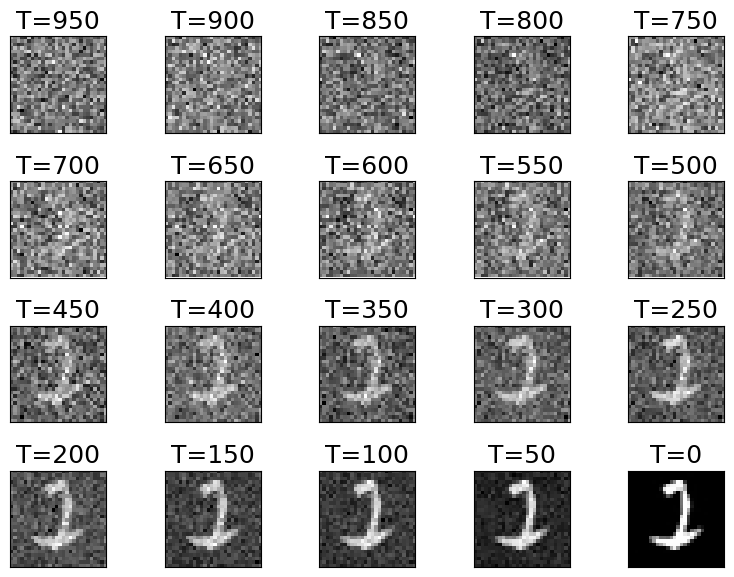

In [ ]:
fig, ax = plt.subplots(nrows=4, ncols=5, figsize=(8, 6))
ax = ax.flatten()

for i in range(20):

    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].grid(False)
    ax[i].imshow(image_history[i].squeeze(), cmap=plt.cm.gray)
    timestep_current = 950 - (i * 50) # Save image each 50 steps
    ax[i].set_title(f"T={timestep_current}")

plt.tight_layout()
plt.show()

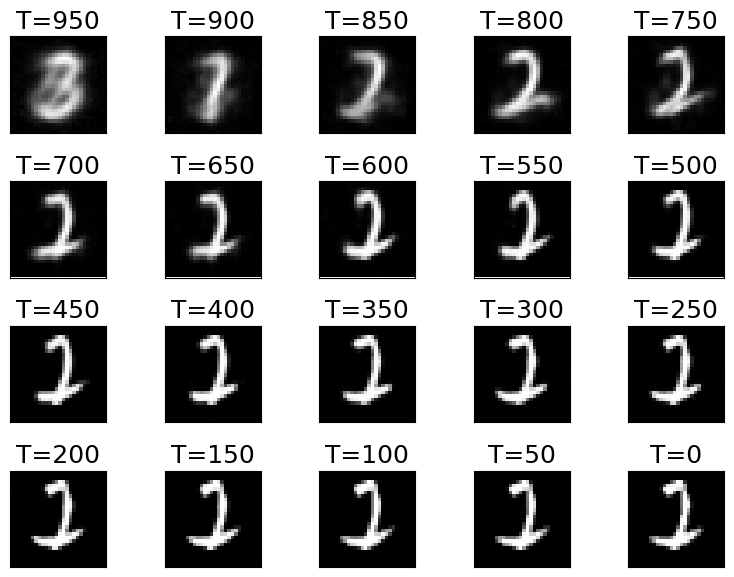

In [ ]:
fig, ax = plt.subplots(nrows=4, ncols=5, figsize=(8, 6))
ax = ax.flatten()

for i in range(20):

    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].grid(False)
    ax[i].imshow(image_prediction[i].squeeze(), cmap=plt.cm.gray)
    timestep_current = 950 - (i * 50) # Save image each 50 steps
    ax[i].set_title(f"T={timestep_current}")

plt.tight_layout()
plt.show()